In [ ]:
# CELL 1: Imports and Load Dataset
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training images shape :", x_train.shape)
print("Training labels shape :", y_train.shape)
print("Test images shape     :", x_test.shape)
print("Test labels shape     :", y_test.shape)
print("Pixel value range     :", x_train.min(), "–", x_train.max())
print("Classes               :", class_names)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step
Training images shape : (50000, 32, 32, 3)
Training labels shape : (50000, 1)
Test images shape     : (10000, 32, 32, 3)
Test labels shape     : (10000, 1)
Pixel value range     : 0 – 255
Classes               : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
# CELL 4 from overall pipeline:
# MEMBER 1: Handling Missing Data
# Step 1: Check if any pixel values or labels are missing (NaN)
nan_in_images = np.isnan(x_train.astype('float32')).any()
nan_in_labels = np.isnan(y_train.astype('float32')).any()

print("Missing values in images:", nan_in_images)
print("Missing values in labels:", nan_in_labels)

# Step 2: Handle missing values if found (remove affected images)
if nan_in_images:
    valid_mask = ~np.isnan(x_train.astype('float32')).any(axis=(1, 2, 3))
    x_train_clean = x_train[valid_mask]
    y_train_clean = y_train[valid_mask]
    print(f"Removed {(~valid_mask).sum()} images with missing values")
else:
    x_train_clean = x_train
    y_train_clean = y_train
    print("No missing values found — no images removed")

Missing values in images: False
Missing values in labels: False
No missing values found — no images removed


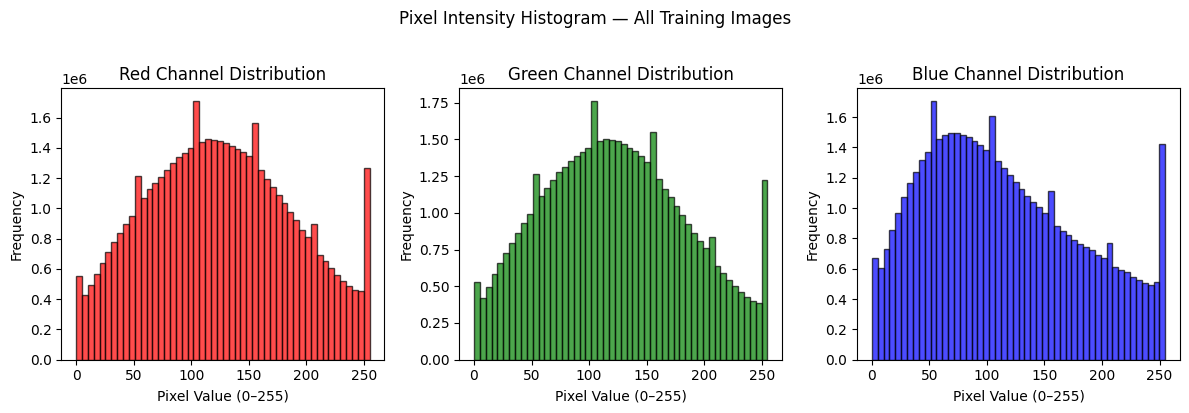

In [ ]:
# CELL 5 from overall pipeline : Pixel intensity histogram — distribution of pixel values per channel
import matplotlib.pyplot as plt
import numpy as np

channel_names = ['Red', 'Green', 'Blue']
colors = ['red', 'green', 'blue']

plt.figure(figsize=(12, 4))

for i, (ch, color) in enumerate(zip(channel_names, colors)):
    plt.subplot(1, 3, i + 1)
    # flatten all images, take one channel, sample 100,000 pixels for speed
    pixel_vals = x_train[:, :, :, i].flatten()
    plt.hist(pixel_vals, bins=50, color=color, alpha=0.7, edgecolor='black')
    plt.title(f'{ch} Channel Distribution')
    plt.xlabel('Pixel Value (0–255)')
    plt.ylabel('Frequency')
    plt.tight_layout()

plt.suptitle('Pixel Intensity Histogram — All Training Images', y=1.02)
plt.tight_layout()
plt.show()